In [6]:
import pandas as pd

In [7]:
df = pd.read_csv("../../data/clean/FPT.VN.cleaned.csv")


In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 4265 entries, 0 to 4264
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   symbol      4265 non-null   str    
 1   date        4265 non-null   str    
 2   open        4265 non-null   float64
 3   high        4265 non-null   float64
 4   low         4265 non-null   float64
 5   close       4265 non-null   float64
 6   adj_close   4265 non-null   float64
 7   volume      4265 non-null   int64  
 8   created_at  4265 non-null   str    
dtypes: float64(5), int64(1), str(3)
memory usage: 300.0 KB


In [16]:
df.isnull().sum()

symbol        0
date          0
open          0
high          0
low           0
close         0
adj_close     0
volume        0
created_at    0
dtype: int64

In [17]:
df.duplicated(subset=["symbol","date"]).sum()

np.int64(0)

In [9]:
df.describe()


,open,high,low,close,adj_close,volume
count,4265.000000,4265.000000,4265.000000,4265.000000,4265.000000,4.265000e+03
mean,33959.937834,34303.517014,33623.868175,33948.545630,30630.056330,3.403910e+06
std,33485.897058,33824.717884,33137.065550,33463.889151,33363.529333,8.213372e+06
min,5547.423828,5616.335938,5530.195801,5564.651855,3532.200684,0.000000e+00
25%,10358.349609,10422.955078,10336.815430,10336.815430,7029.602051,1.060509e+06
50%,16723.216797,16873.876953,16610.222656,16723.216797,13656.482422,2.229659e+06
75%,52601.296875,52984.851562,52141.039062,52601.296875,48250.839844,4.260381e+06
max,134000.000000,135652.171875,133391.296875,134173.906250,129855.726562,4.157099e+08


In [10]:
df.head()

,symbol,date,open,high,low,close,adj_close,volume,created_at
0,FPT.VN,2010-02-22,11646.144531,11646.144531,11439.408203,11508.320312,6976.840332,1133835,2026-08-06 16:24:45.638407
1,FPT.VN,2010-02-23,11232.671875,11301.583984,11025.935547,11094.847656,6726.176758,937571,2026-08-06 16:24:45.638407
2,FPT.VN,2010-02-24,11025.935547,11163.759766,11025.935547,11094.847656,6726.176758,1362024,2026-08-06 16:24:45.638407
3,FPT.VN,2010-02-25,11094.847656,11232.671875,10957.023438,11094.847656,6726.176758,1948932,2026-08-06 16:24:45.638407
4,FPT.VN,2010-02-26,11025.935547,11025.935547,10750.287109,10750.287109,6517.289062,4971986,2026-08-06 16:24:45.638407


# Giải thích các chỉ số trong bảng
## Open: 
- Giá giao dịch đầu tiên/ giá mở cửa của phiên.
- Ví dụ: ngày 12/08 Open = 125,000 -> có nghĩa là phiên giao dịch bắt đầu quanh mức 125,000.
- Open cho biết điểm bắt đầu của biến động giá trong ngày.

## High:
- Giá cao nhất mà cổ phiếu đạt được trong ngày.
- Ví dụ Ngày 12/08 High = 128,000 -> Trong ngày giá từng đạt được 128,000
- High cho biết mức giá tối đa mà thị trường chấp nhận được trong ngày.

## Low: 
- Giá thấp nhất mà cổ phiếu đạt dược trong ngày.
- Ví dụ Ngày 12/08 Low = 123,000 -> Trong ngày giá từng giảm xuống 123,000
- High và Low rất quan trọng vì chúng cho biết biên độ giao động trong ngày

## Close: 
- Giá đóng cửa phiên giao dịch.
- Biến quan trọng trong phân tích chuỗi thời gian 
- Ví dụ: Ngày 11: Close = 124,000, Ngày 12: Close = 127,000. Ta có thể tính lợi suất: return = (127,000 - 124,000)/124,000 = 2,42%
- Giá tăng khoảng 2,42% so với ngày trước.



# Quan hệ giữa Open - High - Low - Close
- Trong một ngày thông thường:  
High >= max(Open,Close)  
và  
Low <= min(Open,Close)
- Ví dụ:  
Open  = 125  
High  = 128  
Low   = 123  
Close = 127

- Giá tăng hay giảm trong ngày?  
So sánh:  
&emsp; Close - Open  
Nếu: Close > Open  
-> Giá tăng 2  
Và ngược lại.



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns


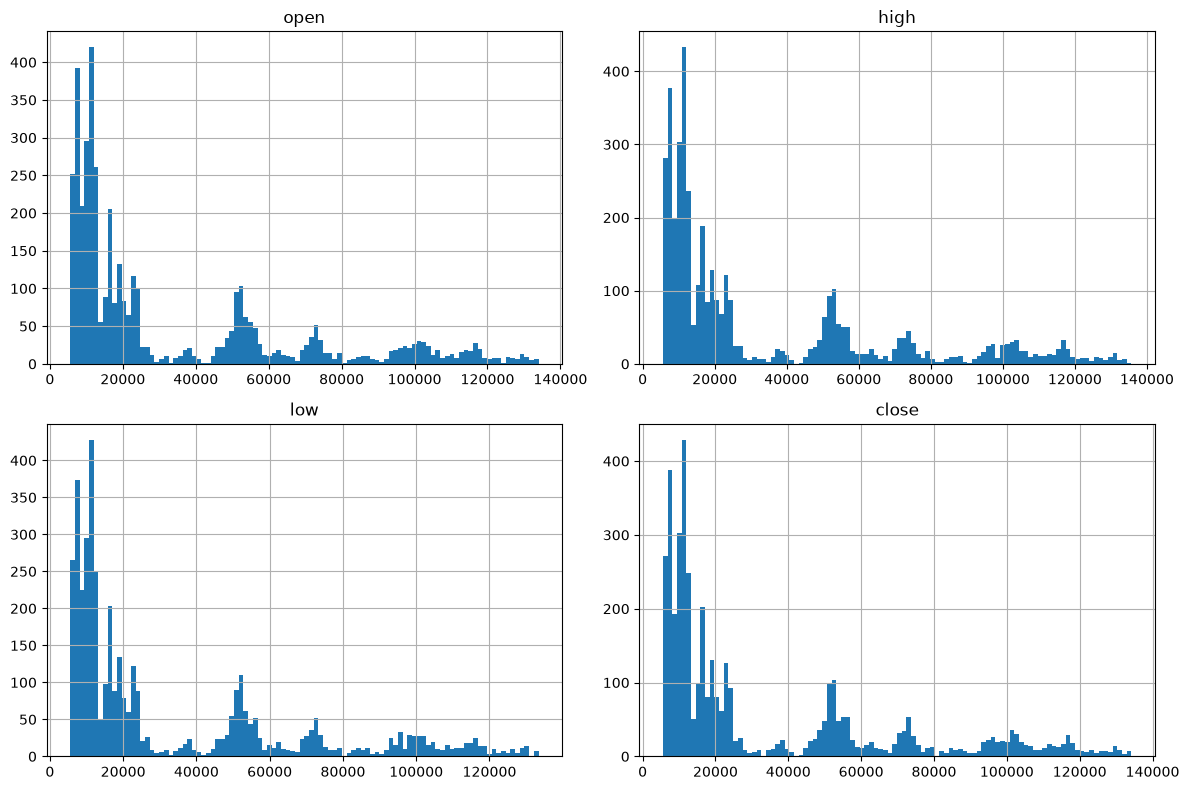

In [13]:
df[["open", "high", "low", "close"]].hist(bins=100,figsize=(12,8))
plt.tight_layout()
plt.show()

## Nhận xét:
### Tổng quan:
- Cả 4 biểu đồ thể hiện mật độ dữ liệu tập trung cực kì cao ở vùng giá thấp (Khoảng 5,000 đến 20,000)
- Phần lớn thời gian giao dịch, giá của tài sản này chỉ nằm trong vùng giá rẻ.
- Tần suất giảm rất nhanh khi giá tăng lên cao. Số lần giá chạm các mốc từ 80,000 đến 140,000 là rất ít (tạo thành phần "đuôi dài" về phía bên phải)  
=> Phân bố lệch rõ rệt

### Chi tiết:
- Đỉnh chính: Vùng giá tập trung từ 10,000 - 20,000 vì xuất hiện nhiều nhất, tần suất > 900
- Đỉnh phụ 1: Vùng giá 50,000 - 60,000 vì tần suất xuất hiện trong khoảng 200 - 250 lần. Cho biết giá từng có giai đoạn tích lũy hoặc giao dịch nhiều quanh vùng này.
- Đỉnh phụ 2: Vùng giá xung quanh 70,000 và 100,000

In [14]:
import seaborn as sns


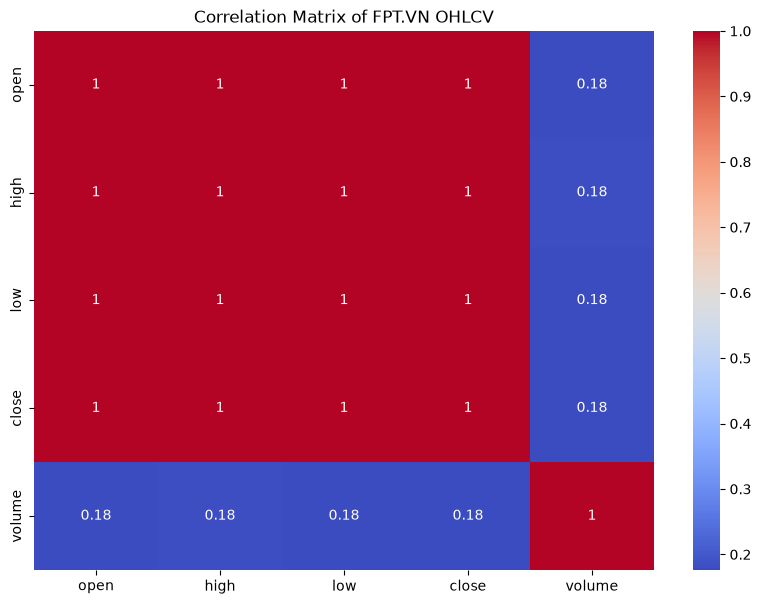

In [15]:
plt.figure(figsize=(10,7))

sns.heatmap(
    df[["open","high","low","close","volume"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix of FPT.VN OHLCV")
plt.show()

## Nhận xét:
#### Nhóm giá (OHLC) đồng biến tuyệt đối (r=1.0)
- Hiện tượng: Cả 4 biến giá tạo thành một khối màu đỏ thẫm với hệ số tương quan đạt mức tối đa (1.0).
- Nhận xét: Biên độ dao động trong một phiên dao dịch của cổ phiếu FPT là rất nhỏ so với tổng mức giá thực tế của nó trên thị trường. Khi tăng/giảm giá ở bất kì điểm nào trong phiên, toàn bộ các mức giá còn lại còn lại đều di chuyển cùng chiều một cách chính xác.
#### Khối lượng (volume) hoàn toàn độc lập với giá (r=0.18)
- Hiện tượng: Khối giao dịch (volume) chỉ có hệ số tương quan 0.18 đối với cả 4 biến giá 
- Nhận xét: Khối lượng giao dịch của cổ phiếu không phụ thuộc vào việc giá cổ phiếu đang cao hay thấp. Việc FPT ở mức giá 20,000 hay 100,000 không làm tăng hay giảm khối lượng giao dịch của nhà đầu tư.

In [18]:
print("High < Low:", (df["high"] < df["low"]).sum())
print("High < Close:", (df["high"] < df["close"]).sum())
print("Low > Close:", (df["low"] > df["close"]).sum())

High < Low: 0
High < Close: 0
Low > Close: 0
